In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

conn = sqlite3.connect("../data/processed/cosmere.db")

def sql_query(query):
    result = pd.read_sql_query(query, conn)
    return result

In [11]:
df = pd.read_sql_query("SELECT * from books", conn)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             19 non-null     str    
 1   series            19 non-null     str    
 2   series_order      19 non-null     int64  
 3   hardcover_id      19 non-null     int64  
 4   release_year      19 non-null     int64  
 5   pages             19 non-null     int64  
 6   rating            19 non-null     float64
 7   ratings_count     19 non-null     int64  
 8   reviews_count     19 non-null     int64  
 9   users_read_count  19 non-null     int64  
 10  has_audiobook     19 non-null     int64  
 11  has_ebook         19 non-null     int64  
 12  genres            19 non-null     str    
 13  moods             19 non-null     str    
 14  content_warnings  19 non-null     str    
 15  description       19 non-null     str    
dtypes: float64(1), int64(9), str(6)
memory usage: 2.5 KB


In [12]:
ml_df = df[['series', 'series_order', 'release_year', 'pages', 'has_audiobook', 'has_ebook', 'rating']]
ml_df

,series,series_order,release_year,pages,has_audiobook,has_ebook,rating
0,Mistborn Era 1,1,2006,541,1,1,4.4689
1,Mistborn Era 1,2,2007,590,1,1,4.3391
2,Mistborn Era 1,3,2007,572,1,1,4.5641
3,Mistborn Era 2,1,2011,325,1,1,4.1172
4,Mistborn Era 2,2,2015,376,1,1,4.2059
5,Mistborn Era 2,3,2016,455,1,1,4.3603
6,Mistborn Era 2,4,2022,507,1,1,4.4460
7,Stormlight Archive,1,2010,1007,1,1,4.6337
8,Stormlight Archive,2,2012,1088,1,1,4.7148
9,Stormlight Archive,3,2017,1243,1,1,4.5739


In [13]:
ml_df = ml_df.drop(['has_audiobook', 'has_ebook'], axis=1)
ml_df

,series,series_order,release_year,pages,rating
0,Mistborn Era 1,1,2006,541,4.4689
1,Mistborn Era 1,2,2007,590,4.3391
2,Mistborn Era 1,3,2007,572,4.5641
3,Mistborn Era 2,1,2011,325,4.1172
4,Mistborn Era 2,2,2015,376,4.2059
5,Mistborn Era 2,3,2016,455,4.3603
6,Mistborn Era 2,4,2022,507,4.4460
7,Stormlight Archive,1,2010,1007,4.6337
8,Stormlight Archive,2,2012,1088,4.7148
9,Stormlight Archive,3,2017,1243,4.5739


In [14]:
le = LabelEncoder()
ml_df['series'] = le.fit_transform(ml_df['series'])

ml_df.head()

,series,series_order,release_year,pages,rating
0,1,1,2006,541,4.4689
1,1,2,2007,590,4.3391
2,1,3,2007,572,4.5641
3,2,1,2011,325,4.1172
4,2,2,2015,376,4.2059


In [15]:
X = ml_df.drop(['rating'], axis=1)
y = ml_df['rating']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (15, 4)
Test set: (4, 4)


In [18]:
# 1. Create the model
model = LinearRegression()

# 2. Train it on the training data
model.fit(X_train, y_train)

# 3. Make predictions on the test data
y_pred = model.predict(X_test)

In [20]:
print(f"Actual ratings:    {list(y_test.round(2))}")
print(f"Predicted ratings: {list(y_pred.round(2))}")

Actual ratings:    [4.47, 4.36, 4.35, 4.34]
Predicted ratings: [np.float64(4.13), np.float64(4.28), np.float64(4.84), np.float64(4.15)]


In [21]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")

Mean Squared Error: 0.1003
R2 Score: -35.3684


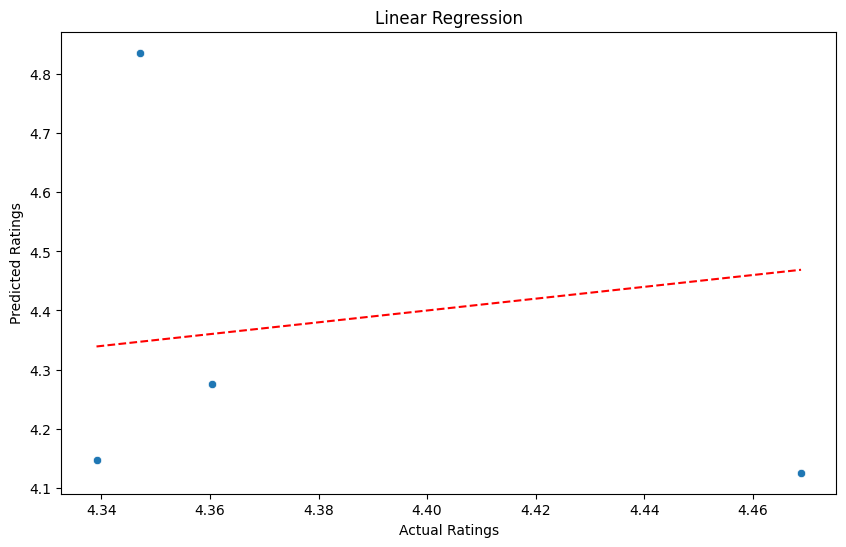

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--') 
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Linear Regression")
plt.show()

In [23]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_
})
print(feature_importance.sort_values('coefficient', ascending=False))

        feature  coefficient
0        series     0.059042
2  release_year     0.015201
3         pages     0.000391
1  series_order    -0.013437
